用 SVD 实现 PCA
数据形状: (150, 4)

SVD 结果:
  U 形状: (150, 4)
  S (奇异值): [20.923 11.709  4.692  1.763]
  V^T 形状: (4, 4)

主成分 (V 的列):
  PC1: [ 0.521 -0.269  0.58   0.565]
  PC2: [-0.377 -0.923 -0.024 -0.067]

解释方差比: [0.73  0.229 0.037 0.005]
前2个主成分累积解释: 0.958


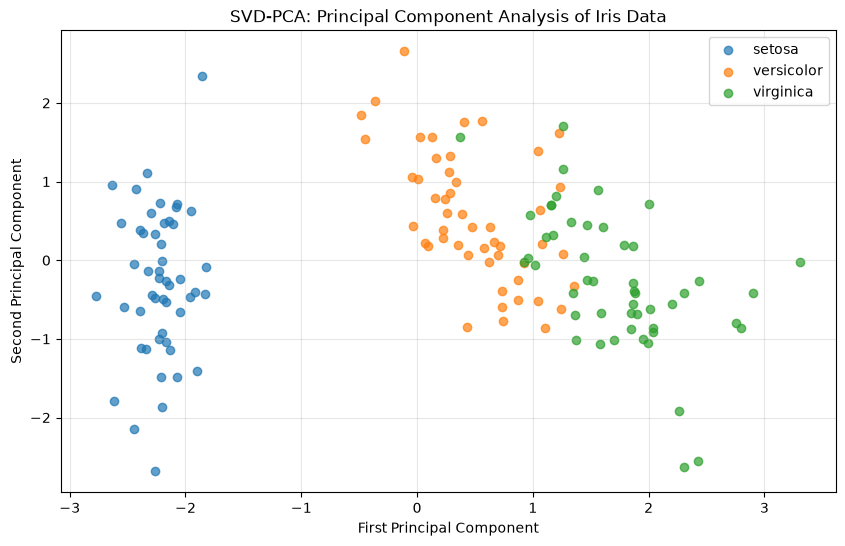


与 sklearn PCA 对比
sklearn 解释方差比: [0.73  0.229]
SVD 解释方差比: [0.73  0.229]
结果一致？ True


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.linalg import svd

# ---- 加载数据 ----
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# ---- 标准化 ----
X_scaled = StandardScaler().fit_transform(X)
print("=" * 60)
print("用 SVD 实现 PCA")
print("=" * 60)
print(f"数据形状: {X_scaled.shape}")

# ---- 中心化 ----
X_centered = X_scaled - np.mean(X_scaled, axis=0)

# ---- SVD ----
U, S, Vt = svd(X_centered, full_matrices=False)
print(f"\nSVD 结果:")
print(f"  U 形状: {U.shape}")
print(f"  S (奇异值): {S[:5].round(3)}")
print(f"  V^T 形状: {Vt.shape}")

# ---- 主成分 ----
components = Vt  # 主成分方向（V 的转置）
print(f"\n主成分 (V 的列):")
for i in range(2):
    print(f"  PC{i+1}: {components[i, :].round(3)}")

# ---- 解释方差比 ----
explained_variance = S**2 / (X_centered.shape[0] - 1)
explained_variance_ratio = explained_variance / np.sum(explained_variance)
print(f"\n解释方差比: {explained_variance_ratio.round(3)}")
print(f"前2个主成分累积解释: {explained_variance_ratio[:2].sum():.3f}")

# ---- 投影到前2个主成分 ----
X_pca = X_centered @ components[:2, :].T

plt.figure(figsize=(10, 6))
for target in [0, 1, 2]:
    mask = y == target
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=iris.target_names[target], alpha=0.7)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('SVD-PCA: Principal Component Analysis of Iris Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- 与 sklearn PCA 对比 ----
from sklearn.decomposition import PCA
pca_sklearn = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

print("\n" + "=" * 60)
print("与 sklearn PCA 对比")
print("=" * 60)
print(f"sklearn 解释方差比: {pca_sklearn.explained_variance_ratio_.round(3)}")
print(f"SVD 解释方差比: {explained_variance_ratio[:2].round(3)}")
print(f"结果一致？ {np.allclose(np.abs(X_pca), np.abs(X_pca_sklearn))}")